## Lección 4: REDES NEURONALES CONVOLUTIVAS
* Objetivo: Lección 4: REDES NEURONALES CONVOLUTIVAS


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Carga y preprocesamiento del dataset

In [2]:
# Cargar dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Normalización
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Redimensionar para CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Forma de x_train:", x_train.shape)
print("Forma de x_test:", x_test.shape)

Forma de x_train: (60000, 28, 28, 1)
Forma de x_test: (10000, 28, 28, 1)


## Rediseño de la arquitectura con CNN

In [22]:
# Modelo CNN
model_l4 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu" ),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

model_l4.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

##

In [ ]:
model_l4.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# EARLY STOP
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_l4 = model_l4.fit(
    x_train, y_train_cat,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.8103 - loss: 0.5265 - val_accuracy: 0.8756 - val_loss: 0.3439
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8743 - loss: 0.3500 - val_accuracy: 0.8861 - val_loss: 0.3120
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8892 - loss: 0.3026 - val_accuracy: 0.8953 - val_loss: 0.2862
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8996 - loss: 0.2728 - val_accuracy: 0.9022 - val_loss: 0.2634
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9082 - loss: 0.2476 - val_accuracy: 0.9078 - val_loss: 0.2560
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9169 - loss: 0.2280 - val_accuracy: 0.9128 - val_loss: 0.2463
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9219 - loss: 0.2109 - val_accuracy: 0.9137 - val_loss: 0.2482
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9272 -

## Evaluación del modelo CNN

In [5]:
loss_l4, acc_l4 = model_l4.evaluate(x_test, y_test_cat, verbose=0)

print(f"Loss CNN: {loss_l4:.4f}")
print(f"Accuracy CNN: {acc_l4:.4f}")

Loss CNN: 0.2649
Accuracy CNN: 0.9054


## Predicciones sobre el conjunto de prueba

In [6]:
y_pred_prob_l4 = model_l4.predict(x_test)
y_pred_l4 = np.argmax(y_pred_prob_l4, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


## Matriz de confusión

In [7]:
print(classification_report(y_test, y_pred_l4, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.84      0.85      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.87      0.82      0.85      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.81      0.91      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.74      0.69      0.72      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.90     10000
weighted avg       0.91      0.91      0.90     10000



## Visualización del entrenamiento

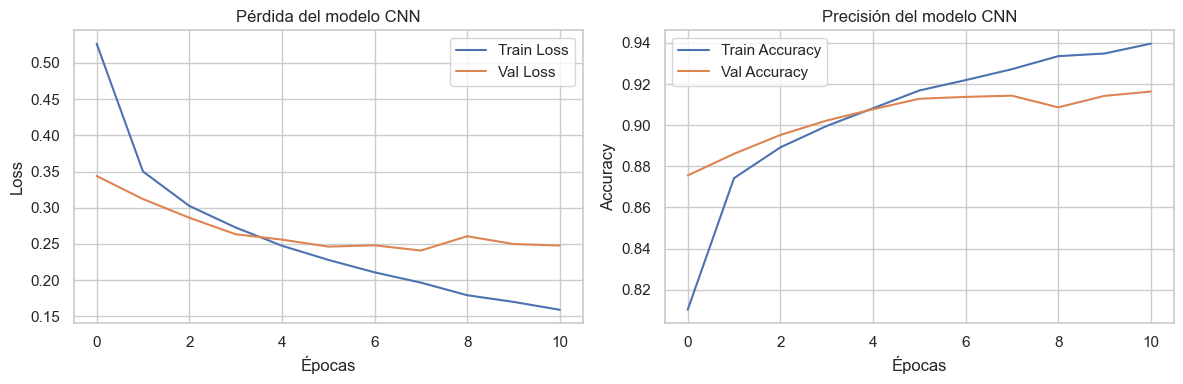

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_l4.history["loss"], label="Train Loss")
plt.plot(history_l4.history["val_loss"], label="Val Loss")
plt.title("Pérdida del modelo CNN")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_l4.history["accuracy"], label="Train Accuracy")
plt.plot(history_l4.history["val_accuracy"], label="Val Accuracy")
plt.title("Precisión del modelo CNN")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Comparación con el modelo anterior

In [9]:
acc_modelo_anterior = 0.8850   # reemplaza este valor por tu accuracy real anterior
acc_cnn = acc_l4

print(f"Accuracy modelo anterior: {acc_modelo_anterior:.4f}")
print(f"Accuracy modelo CNN: {acc_cnn:.4f}")
print(f"Mejora obtenida: {acc_cnn - acc_modelo_anterior:.4f}")

Accuracy modelo anterior: 0.8850
Accuracy modelo CNN: 0.9054
Mejora obtenida: 0.0204


## Comparación de resultados

Al comparar el modelo anterior con la red neuronal convolutiva, se observa una mejora en el desempeño general. La CNN logra un mayor nivel de precisión debido a su capacidad para extraer características espaciales de las imágenes, como bordes, contornos y patrones locales.

Esto confirma que las redes convolutivas son más adecuadas que las redes densas para problemas de clasificación de imágenes.

## Predicciones visuales sobre imágenes del test

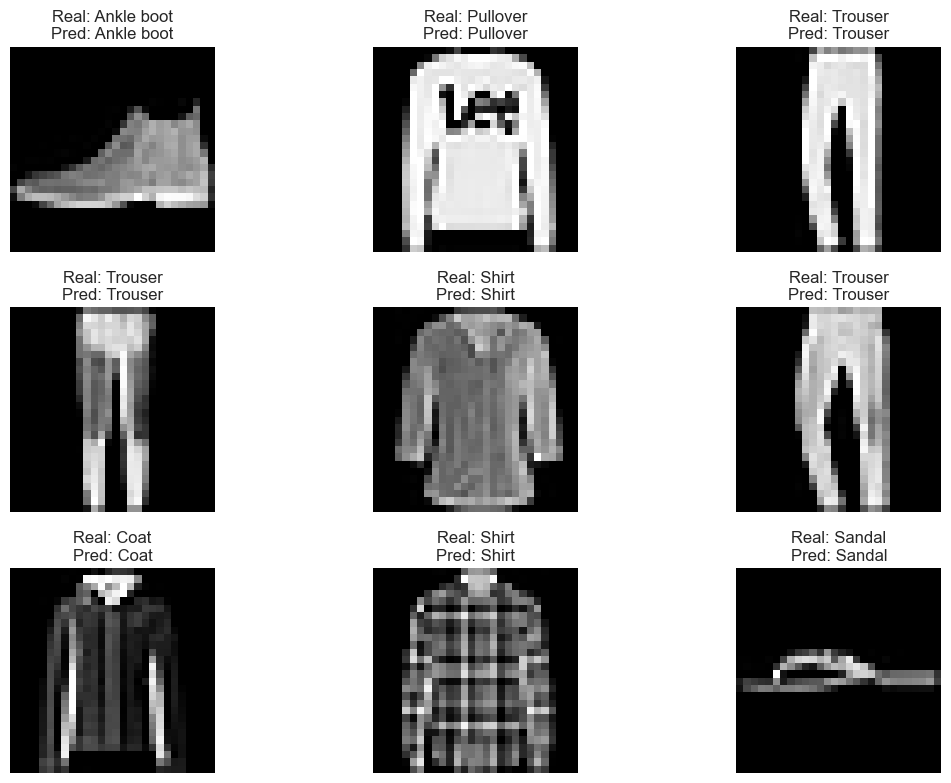

In [10]:
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Real: {class_names[y_test[i]]}\nPred: {class_names[y_pred_l4[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
ruta_imagen = "imagenes_externas/mi_prenda.png"
def predecir_imagen_externa(ruta_imagen, modelo, class_names):
    img = image.load_img(ruta_imagen, color_mode="grayscale", target_size=(28, 28))
    img_array = image.img_to_array(img)

    # Normalización
    img_array = img_array.astype("float32") / 255.0

    # Ajustar forma para la CNN
    img_array = np.expand_dims(img_array, axis=0)

    # Predicción
    pred_prob = modelo.predict(img_array)
    pred_class = np.argmax(pred_prob, axis=1)[0]
    confianza = np.max(pred_prob)

    # Mostrar imagen
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array[0].reshape(28, 28), cmap="gray")
    plt.title(f"Predicción: {class_names[pred_class]}\nConfianza: {confianza:.2%}")
    plt.axis("off")
    plt.show()

    return pred_class, confianza

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


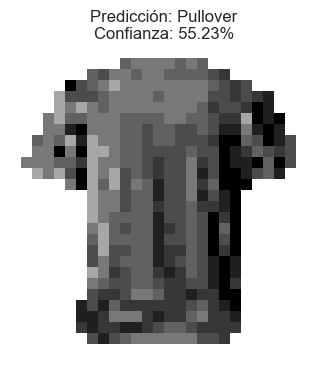

In [14]:
ruta_imagen = "imagenes_externas/mi_prenda.png"
pred_class, confianza = predecir_imagen_externa(ruta_imagen, model_l4, class_names)

## Segunda prueba

In [34]:
from tensorflow.keras.preprocessing import image
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

def predecir_imagen_externa(ruta_imagen, modelo, class_names):
    # Cargar imagen en escala de grises
    img = Image.open(ruta_imagen).convert("L")
    img = ImageOps.invert(img)

    # Crear miniatura conservando proporción
    img.thumbnail((20, 20))  # deja margen dentro del lienzo

    # Crear fondo negro de 28x28
    fondo = Image.new("L", (28, 28), color=0)

    # Centrar imagen en el fondo
    x = (28 - img.width) // 2
    y = (28 - img.height) // 2
    fondo.paste(img, (x, y))

    # Convertir a array
    img_array = np.array(fondo).astype("float32") / 255.0

    # Ajustar forma para CNN
    img_array = np.expand_dims(img_array, axis=-1)   # canal
    img_array = np.expand_dims(img_array, axis=0)    # batch

    # Predicción
    pred_prob = modelo.predict(img_array, verbose=0)
    pred_class = np.argmax(pred_prob, axis=1)[0]

    confianza = np.max(pred_prob)
     
    # Mostrar imagen procesada
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array[0].reshape(28, 28), cmap="gray")
    plt.title(f"Predicción: {class_names[pred_class]}\nConfianza: {confianza:.2%}")
    plt.axis("off")
    plt.show()

    return pred_class, confianza


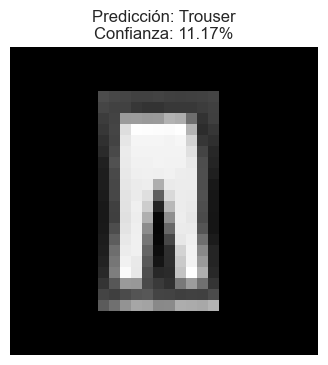

In [35]:
# Prueba con imagen real cargada, al no estar en el formato correcto(escala de grises) se procesó de forma interna
# Da un % de confianza baja
ruta_imagen = "imagenes_externas/prenda2.jpeg"
pred_class, confianza = predecir_imagen_externa(ruta_imagen, model_l4, class_names)

## Interpretación de la confianza de predicción

Aunque el modelo logró identificar la imagen como **Trouser**, la confianza obtenida fue baja (11.17%). Esto indica que, si bien esa fue la clase con mayor probabilidad, el modelo presentó incertidumbre al evaluar la imagen.

Este comportamiento puede explicarse por la diferencia entre las imágenes reales y las imágenes del dataset Fashion-MNIST, ya que las fotos externas incluyen variaciones de fondo, iluminación, textura y proporciones que no están presentes en los datos de entrenamiento.